In [6]:
import os
import rasterio
import numpy as np
import pandas as pd

# ---------------------------------------------------
# 1. SHOW CURRENT LOCATION
# ---------------------------------------------------

print("CURRENT WORKING DIRECTORY:")
print(os.getcwd())

print("\nFILES/FOLDERS AVAILABLE HERE:")
items = os.listdir()

for item in items:
    print(item)


# ---------------------------------------------------
# 2. FIND THE NDVI FOLDER
# ---------------------------------------------------

ndvi_folder = None

for root, dirs, files in os.walk("."):
    for directory in dirs:
        if "ndvi" in directory.lower():
            ndvi_folder = os.path.join(root, directory)
            break

    if ndvi_folder:
        break


# ---------------------------------------------------
# 3. CHECK WHETHER NDVI FOLDER WAS FOUND
# ---------------------------------------------------

if ndvi_folder is None:

    print("\n❌ NDVI folder was NOT found automatically.")
    print("Check the folder names shown above.")

else:

    print("\n✅ NDVI folder found:")
    print(ndvi_folder)

    print("\nTIFF files inside NDVI folder:")

    tif_files = []

    for file in os.listdir(ndvi_folder):

        if file.lower().endswith(".tif"):

            tif_files.append(file)

            print(file)


# ---------------------------------------------------
# 4. READ ALL NDVI TIFF FILES
# ---------------------------------------------------

    years = []
    ndvi_means = []

    for file in sorted(tif_files):

        print("\nProcessing:", file)

        # Extract year from filename
        # Example: NDVI_2015.tif → 2015

        year = None

        for part in file.replace(".tif", "").split("_"):

            if part.isdigit() and len(part) == 4:
                year = int(part)
                break


        if year is None:

            print("⚠️ Could not find year in:", file)

            continue


        # Full file path

        path = os.path.join(ndvi_folder, file)


        # Read TIFF

        with rasterio.open(path) as src:

            data = src.read(1).astype(float)

            # Convert NoData values to NaN

            if src.nodata is not None:

                data[data == src.nodata] = np.nan


        # Calculate mean NDVI

        mean_value = np.nanmean(data)


        # Save year and mean

        years.append(year)

        ndvi_means.append(mean_value)


        print(
            "Year:",
            year,
            "| Mean NDVI:",
            mean_value
        )


# ---------------------------------------------------
# 5. CREATE DATAFRAME
# ---------------------------------------------------

    df_ndvi = pd.DataFrame({

        "Year": years,

        "NDVI": ndvi_means

    })


# ---------------------------------------------------
# 6. SORT BY YEAR
# ---------------------------------------------------

    df_ndvi = df_ndvi.sort_values(
        "Year"
    ).reset_index(
        drop=True
    )


# ---------------------------------------------------
# 7. SHOW FINAL RESULT
# ---------------------------------------------------

    print("\n")
    print("===================================")

    print("FINAL NDVI DATASET")

    print("===================================")

    print(df_ndvi)


# ---------------------------------------------------
# 8. SAVE AS CSV
# ---------------------------------------------------

    df_ndvi.to_csv(

        "NDVI_yearly_mean.csv",

        index=False

    )


    print("\n✅ CSV FILE CREATED:")
    print("NDVI_yearly_mean.csv")

CURRENT WORKING DIRECTORY:
e:\Major-project\Climate-Impact-Assessment-main\Climate-Impact-Assessment-main\frontend

FILES/FOLDERS AVAILABLE HERE:
bun.lock
components.json
eslint.config.js
gitignore
index.html
node_modules
package-lock.json
package.json
postcss.config.js
README.md
src
tailwind.config.ts
train_model.ipynb
tsconfig.app.json
tsconfig.json
tsconfig.node.json
vite.config.ts
vitest.config.ts

❌ NDVI folder was NOT found automatically.
Check the folder names shown above.


In [7]:
import os

parent_folder = ".."

print("FILES AND FOLDERS ONE LEVEL UP:\n")

for item in os.listdir(parent_folder):
    print(item)
    

FILES AND FOLDERS ONE LEVEL UP:

.gitignore
backend
frontend
package-lock.json
package.json


In [8]:
import os

parent_folder = ".."

print("FILES AND FOLDERS ONE LEVEL UP:\n")

for item in os.listdir(parent_folder):
    print(item)

FILES AND FOLDERS ONE LEVEL UP:

.gitignore
backend
frontend
package-lock.json
package.json


In [9]:
import os

print("Searching for .tif files...")
print()

found = []

for root, dirs, files in os.walk(".."):
    # Skip node_modules because it can contain thousands of files
    dirs[:] = [d for d in dirs if d != "node_modules"]

    for file in files:
        if file.lower().endswith((".tif", ".tiff")):
            found.append(os.path.join(root, file))

print("Number of TIFF files found:", len(found))
print()

for file in found[:30]:
    print(file)
    

Searching for .tif files...

Number of TIFF files found: 0



In [10]:
import os

for drive in ["C:\\", "D:\\", "E:\\"]:

    if os.path.exists(drive):
        print("\nSearching:", drive)

        count = 0

        for root, dirs, files in os.walk(drive):

            for file in files:

                if file.lower().endswith(".tif"):

                    print(os.path.join(root, file))

                    count += 1

                    if count >= 20:
                        raise SystemExit


Searching: C:\
C:\Users\HP\AppData\Local\Programs\Python\Python310\Lib\site-packages\skimage\data\multipage.tif
C:\Users\HP\AppData\Local\Programs\Python\Python310\Lib\site-packages\skimage\data\multipage_rgb.tif
C:\Windows\servicing\LCU\Package_for_RollupFix~31bf3856ad364e35~amd64~~19041.6466.1.0\amd64_microsoft-windows-fax-common.resources_31bf3856ad364e35_10.0.19041.3636_ar-sa_29a6b4f32701e522\f\welcomefax.tif
C:\Windows\servicing\LCU\Package_for_RollupFix~31bf3856ad364e35~amd64~~19041.6466.1.0\amd64_microsoft-windows-fax-common.resources_31bf3856ad364e35_10.0.19041.3636_bg-bg_cfe6967c17823679\f\welcomefax.tif
C:\Windows\servicing\LCU\Package_for_RollupFix~31bf3856ad364e35~amd64~~19041.6466.1.0\amd64_microsoft-windows-fax-common.resources_31bf3856ad364e35_10.0.19041.3636_cs-cz_7af00d17050a12a4\f\welcomefax.tif
C:\Windows\servicing\LCU\Package_for_RollupFix~31bf3856ad364e35~amd64~~19041.6466.1.0\amd64_microsoft-windows-fax-common.resources_31bf3856ad364e35_10.0.19041.3636_da-dk_1829

SystemExit: 

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\IPython\core\interactiveshell.py:3783: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [11]:
import os

print("Current location:")
print(os.getcwd())

print("\nClimate_Project contents:")
print(os.listdir(r"E:\Major-project\Climate_Project"))

Current location:
e:\Major-project\Climate-Impact-Assessment-main\Climate-Impact-Assessment-main\frontend

Climate_Project contents:
['check_rasters.py', 'NDVI', 'Rainfall', 'Temperature', 'venv']


In [12]:
import os
import rasterio
import numpy as np
import pandas as pd

folder = r"E:\Major-project\Climate_Project\NDVI"

years = []
ndvi_means = []

for file in sorted(os.listdir(folder)):

    if file.endswith(".tif"):

        print("Processing:", file)

        # Extract year from filename
        year = int(file.split("_")[-1].replace(".tif", ""))

        path = os.path.join(folder, file)

        with rasterio.open(path) as src:
            data = src.read(1).astype(float)

            if src.nodata is not None:
                data[data == src.nodata] = np.nan

        mean_ndvi = np.nanmean(data)

        years.append(year)
        ndvi_means.append(mean_ndvi)

df_ndvi = pd.DataFrame({
    "Year": years,
    "NDVI": ndvi_means
})

print("\nNDVI Dataset:")
print(df_ndvi)

Processing: India_NDVI_2015.tif
Processing: India_NDVI_2016.tif
Processing: India_NDVI_2017.tif
Processing: India_NDVI_2018.tif
Processing: India_NDVI_2019.tif
Processing: India_NDVI_2020.tif
Processing: India_NDVI_2021.tif
Processing: India_NDVI_2022.tif
Processing: India_NDVI_2023.tif
Processing: India_NDVI_2024.tif
Processing: India_NDVI_2025.tif

NDVI Dataset:
    Year      NDVI
0   2015  0.331479
1   2016  0.324283
2   2017  0.332708
3   2018  0.320450
4   2019  0.330984
5   2020  0.345677
6   2021  0.341066
7   2022  0.343605
8   2023  0.344653
9   2024  0.346871
10  2025  0.355643


In [13]:
import os
import rasterio
import numpy as np
import pandas as pd

folder = r"E:\Major-project\Climate_Project\Rainfall"

years = []
rainfall_means = []

for file in sorted(os.listdir(folder)):

    if file.endswith(".tif"):

        print("Processing:", file)

        year = int(file.split("_")[-1].replace(".tif", ""))

        path = os.path.join(folder, file)

        with rasterio.open(path) as src:
            data = src.read(1).astype(float)

            if src.nodata is not None:
                data[data == src.nodata] = np.nan

        mean_rainfall = np.nanmean(data)

        years.append(year)
        rainfall_means.append(mean_rainfall)

df_rainfall = pd.DataFrame({
    "Year": years,
    "Rainfall": rainfall_means
})

print("\nRainfall Dataset:")
print(df_rainfall)

Processing: India_Rainfall_2015.tif
Processing: India_Rainfall_2016.tif
Processing: India_Rainfall_2017.tif
Processing: India_Rainfall_2018.tif
Processing: India_Rainfall_2019.tif
Processing: India_Rainfall_2020.tif
Processing: India_Rainfall_2021.tif
Processing: India_Rainfall_2022.tif
Processing: India_Rainfall_2023.tif
Processing: India_Rainfall_2024.tif
Processing: India_Rainfall_2025.tif

Rainfall Dataset:
    Year     Rainfall
0   2015   872.427692
1   2016   922.058776
2   2017   956.095115
3   2018   903.290950
4   2019   955.815937
5   2020   965.726371
6   2021   939.891171
7   2022   920.617509
8   2023   851.338850
9   2024   971.000125
10  2025  1018.389771


In [15]:
df = df_ndvi.merge(df_temp, on="Year")
df = df.merge(df_rainfall, on="Year")

print(df)


    Year      NDVI  Temperature     Rainfall
0   2015  0.331479    13.685037   872.427692
1   2016  0.324283    14.338613   922.058776
2   2017  0.332708    13.968609   956.095115
3   2018  0.320450    13.757282   903.290950
4   2019  0.330984    13.456346   955.815937
5   2020  0.345677    13.596646   965.726371
6   2021  0.341066    13.841328   939.891171
7   2022  0.343605    13.936557   920.617509
8   2023  0.344653    13.907285   851.338850
9   2024  0.346871    14.365396   971.000125
10  2025  0.355643    14.162097  1018.389771


In [17]:
import rasterio

path = r"E:\Major-project\Climate_Project\NDVI\India_NDVI_2025.tif"

with rasterio.open(path) as src:
    print("Shape:", src.shape)
    print("CRS:", src.crs)
    print("Bounds:", src.bounds)
    print("NoData:", src.nodata)

Shape: (14681, 13360)
CRS: EPSG:4326
Bounds: BoundingBox(left=67.99797543142718, bottom=5.998500309708106, right=98.0017059210192, top=38.968917025104844)
NoData: None


In [19]:
import rasterio

ndvi_file = r"E:\Major-project\Climate_Project\NDVI\India_NDVI_2025.tif"
temp_file = r"E:\Major-project\Climate_Project\Temperature\India_Temperature_2025.tif"
rain_file = r"E:\Major-project\Climate_Project\Rainfall\India_Rainfall_2025.tif"

for file in [ndvi_file, temp_file, rain_file]:

    with rasterio.open(file) as src:

        print("\nFILE:", file)
        print("Shape:", src.shape)
        print("CRS:", src.crs)
        print("Transform:", src.transform)
        


FILE: E:\Major-project\Climate_Project\NDVI\India_NDVI_2025.tif
Shape: (14681, 13360)
CRS: EPSG:4326
Transform: | 0.00, 0.00, 68.00|
| 0.00,-0.00, 38.97|
| 0.00, 0.00, 1.00|

FILE: E:\Major-project\Climate_Project\Temperature\India_Temperature_2025.tif
Shape: (368, 335)
CRS: EPSG:4326
Transform: | 0.09, 0.00, 67.91|
| 0.00,-0.09, 38.99|
| 0.00, 0.00, 1.00|

FILE: E:\Major-project\Climate_Project\Rainfall\India_Rainfall_2025.tif
Shape: (735, 669)
CRS: EPSG:4326
Transform: | 0.04, 0.00, 67.96|
| 0.00,-0.04, 38.99|
| 0.00, 0.00, 1.00|


In [20]:
import rasterio

files = {
    "NDVI": r"E:\Major-project\Climate_Project\NDVI\India_NDVI_2025.tif",
    "Rainfall": r"E:\Major-project\Climate_Project\Rainfall\India_Rainfall_2025.tif",
    "Temperature": r"E:\Major-project\Climate_Project\Temperature\India_Temperature_2025.tif"
}

for name, path in files.items():

    with rasterio.open(path) as src:

        print("\n", name)

        print("Width :", src.width)
        print("Height:", src.height)

        print("Bounds:", src.bounds)
        


 NDVI
Width : 13360
Height: 14681
Bounds: BoundingBox(left=67.99797543142718, bottom=5.998500309708106, right=98.0017059210192, top=38.968917025104844)

 Rainfall
Width : 669
Height: 735
Bounds: BoundingBox(left=67.9575512436418, bottom=5.973796639394813, right=98.0061974974398, top=38.98688333078723)

 Temperature
Width : 335
Height: 368
Bounds: BoundingBox(left=67.91263547943582, bottom=5.928880875188838, right=98.00619749743979, top=38.98688333078723)


In [21]:
import rasterio
import numpy as np

ndvi_path = r"E:\Major-project\Climate_Project\NDVI\India_NDVI_2025.tif"

with rasterio.open(ndvi_path) as src:
    ndvi = src.read(1)

print("Shape:", ndvi.shape)

valid_pixels = np.where(~np.isnan(ndvi))

print("Valid rows:", len(valid_pixels[0]))


Shape: (14681, 13360)
Valid rows: 126545457


In [22]:
import numpy as np
import rasterio

ndvi_path = r"E:\Major-project\Climate_Project\NDVI\India_NDVI_2025.tif"

with rasterio.open(ndvi_path) as src:
    ndvi = src.read(1)

print("Minimum:", np.nanmin(ndvi))
print("Maximum:", np.nanmax(ndvi))
print("Mean:", np.nanmean(ndvi))

Minimum: -0.2
Maximum: 0.9957
Mean: 0.35564286483041996


In [24]:
# NDVI normalization
df['NDVI_norm'] = (
    (df['NDVI'] - df['NDVI'].min()) /
    (df['NDVI'].max() - df['NDVI'].min())
)

# Rainfall normalization
df['Rainfall_norm'] = (
    (df['Rainfall'] - df['Rainfall'].min()) /
    (df['Rainfall'].max() - df['Rainfall'].min())
)

# Temperature normalization
df['Temp_norm'] = (
    (df['Temperature'] - df['Temperature'].min()) /
    (df['Temperature'].max() - df['Temperature'].min())
)

print(df)



    Year      NDVI  Temperature     Rainfall  NDVI_norm  Rainfall_norm  \
0   2015  0.331479    13.685037   872.427692   0.313382       0.126242   
1   2016  0.324283    14.338613   922.058776   0.108914       0.423344   
2   2017  0.332708    13.968609   956.095115   0.348298       0.627092   
3   2018  0.320450    13.757282   903.290950   0.000000       0.310996   
4   2019  0.330984    13.456346   955.815937   0.299326       0.625421   
5   2020  0.345677    13.596646   965.726371   0.716818       0.684746   
6   2021  0.341066    13.841328   939.891171   0.585793       0.530092   
7   2022  0.343605    13.936557   920.617509   0.657950       0.414716   
8   2023  0.344653    13.907285   851.338850   0.687723       0.000000   
9   2024  0.346871    14.365396   971.000125   0.750743       0.716316   
10  2025  0.355643    14.162097  1018.389771   1.000000       1.000000   

    Temp_norm  
0    0.251571  
1    0.970537  
2    0.563514  
3    0.331045  
4    0.000000  
5    0.154337  

In [25]:
# Climate Condition Index (CCI)

df['CCI'] = (
    0.4 * df['NDVI_norm']
    + 0.4 * df['Rainfall_norm']
    + 0.2 * (1 - df['Temp_norm'])
)

print(df[['Year', 'CCI']])

    Year       CCI
0   2015  0.325535
1   2016  0.218796
2   2017  0.477453
3   2018  0.258189
4   2019  0.569898
5   2020  0.729758
6   2021  0.561654
7   2022  0.523415
8   2023  0.375878
9   2024  0.586824
10  2025  0.844728


In [26]:
from xgboost import XGBRegressor

# Features
X = df[['Year']]

# Target
y = df['CCI']

# Model
cci_model = XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

# Train
cci_model.fit(X, y)

print("CCI Model Trained Successfully!")

CCI Model Trained Successfully!


In [27]:
import os

print("Temperature files:", len(os.listdir(r"E:\Major-project\Climate_Project\Temperature")))
print("Rainfall files:", len(os.listdir(r"E:\Major-project\Climate_Project\Rainfall")))
print("NDVI files:", len(os.listdir(r"E:\Major-project\Climate_Project\NDVI")))

Temperature files: 11
Rainfall files: 11
NDVI files: 11


In [32]:
import pandas as pd

future_years = pd.DataFrame({
    'Year':[2026,2027,2028,2029,2030,2031,2032]
})

future_cci = cci_model.predict(future_years)

prediction_df = pd.DataFrame({
    'Year': future_years['Year'],
    'Predicted_CCI': future_cci
})

print(prediction_df)


   Year  Predicted_CCI
0  2026       0.812939
1  2027       0.812939
2  2028       0.812939
3  2029       0.812939
4  2030       0.812939
5  2031       0.812939
6  2032       0.812939


In [33]:
from sklearn.linear_model import LinearRegression
import pandas as pd

X = df[['Year']]
y = df['CCI']

lr_model = LinearRegression()
lr_model.fit(X, y)

future_years = pd.DataFrame({
    'Year':[2026,2027,2028,2029,2030,2031,2032]
})

future_cci = lr_model.predict(future_years)

prediction_df = pd.DataFrame({
    'Year': future_years['Year'],
    'Predicted_CCI': future_cci
})

print(prediction_df)

   Year  Predicted_CCI
0  2026       0.731224
1  2027       0.770184
2  2028       0.809143
3  2029       0.848103
4  2030       0.887062
5  2031       0.926022
6  2032       0.964982


In [34]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import pandas as pd

X = df[['Year']]
y = df['Rainfall']

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

future_years = pd.DataFrame({
    'Year':[2026,2027,2028,2029,2030,2031,2032]
})

future_poly = poly.transform(future_years)

predictions = model.predict(future_poly)

result = pd.DataFrame({
    'Year':future_years['Year'],
    'Predicted_Rainfall':predictions
})

print(result)

   Year  Predicted_Rainfall
0  2026          968.646918
1  2027          974.393506
2  2028          980.142931
3  2029          985.895191
4  2030          991.650286
5  2031          997.408218
6  2032         1003.168985


In [ ]:
from sklearn.metrics import r2_score

# Linear Regression
from sklearn.linear_model import LinearRegression

lin_model = LinearRegression()
lin_model.fit(df[['Year']], df['Rainfall'])

lin_pred = lin_model.predict(df[['Year']])

lin_r2 = r2_score(df['Rainfall'], lin_pred)

print("Linear R² =", lin_r2)

In [35]:
import os
import rasterio
import numpy as np
import pandas as pd

folder = r"E:\Major-project\Climate_Project\Temperature"

years = []
temperature_means = []

for file in sorted(os.listdir(folder)):

    if file.endswith(".tif"):

        print("Processing:", file)

        year = int(file.split("_")[-1].replace(".tif", ""))

        path = os.path.join(folder, file)

        with rasterio.open(path) as src:
            data = src.read(1).astype(float)

            if src.nodata is not None:
                data[data == src.nodata] = np.nan

        mean_temp = np.nanmean(data)

        years.append(year)
        temperature_means.append(mean_temp)

df_temp = pd.DataFrame({
    "Year": years,
    "Temperature": temperature_means
})

print("\nTemperature Dataset:")
print(df_temp)

Processing: India_Temperature_2015.tif
Processing: India_Temperature_2016.tif
Processing: India_Temperature_2017.tif
Processing: India_Temperature_2018.tif
Processing: India_Temperature_2019.tif
Processing: India_Temperature_2020.tif
Processing: India_Temperature_2021.tif
Processing: India_Temperature_2022.tif
Processing: India_Temperature_2023.tif
Processing: India_Temperature_2024.tif
Processing: India_Temperature_2025.tif

Temperature Dataset:
    Year  Temperature
0   2015    13.685037
1   2016    14.338613
2   2017    13.968609
3   2018    13.757282
4   2019    13.456346
5   2020    13.596646
6   2021    13.841328
7   2022    13.936557
8   2023    13.907285
9   2024    14.365396
10  2025    14.162097


In [36]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lin_model = LinearRegression()

lin_model.fit(df[['Year']], df['Rainfall'])

lin_pred = lin_model.predict(df[['Year']])

lin_r2 = r2_score(df['Rainfall'], lin_pred)

print("Linear R² =", lin_r2)

Linear R² = 0.1612117271348117


In [37]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(df[['Year']])

poly_model = LinearRegression()

poly_model.fit(X_poly, df['Rainfall'])

poly_pred = poly_model.predict(X_poly)

poly_r2 = r2_score(df['Rainfall'], poly_pred)

print("Polynomial R² =", poly_r2)

Polynomial R² = 0.16124345933597128


In [38]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

for column in ['Temperature', 'NDVI', 'CCI']:
    model = LinearRegression()
    model.fit(df[['Year']], df[column])

    pred = model.predict(df[['Year']])

    r2 = r2_score(df[column], pred)

    print(column, "R² =", r2)

Temperature R² = 0.10063635985045172
NDVI R² = 0.7277661483404653
CCI R² = 0.44854980501919395


In [29]:
import os

print("Current location:")
print(os.getcwd())

print("\nFiles and folders here:")
print(os.listdir())


Current location:
e:\Major-project\Climate-Impact-Assessment-main\Climate-Impact-Assessment-main\frontend

Files and folders here:
['bun.lock', 'components.json', 'eslint.config.js', 'gitignore', 'index.html', 'node_modules', 'package-lock.json', 'package.json', 'postcss.config.js', 'README.md', 'src', 'tailwind.config.ts', 'train_model.ipynb', 'tsconfig.app.json', 'tsconfig.json', 'tsconfig.node.json', 'vite.config.ts', 'vitest.config.ts']


In [39]:
from sklearn.linear_model import LinearRegression
import pandas as pd

# Future years
future_years = pd.DataFrame({
    'Year': [2026, 2027, 2028, 2029, 2030, 2031, 2032]
})

# ---------- NDVI ----------
ndvi_model = LinearRegression()
ndvi_model.fit(df[['Year']], df['NDVI'])

future_ndvi = ndvi_model.predict(future_years)

# ---------- Rainfall ----------
rain_model = LinearRegression()
rain_model.fit(df[['Year']], df['Rainfall'])

future_rain = rain_model.predict(future_years)

# ---------- Temperature ----------
temp_model = LinearRegression()
temp_model.fit(df[['Year']], df['Temperature'])

future_temp = temp_model.predict(future_years)

# Combine all predictions
future_df = pd.DataFrame({
    'Year': future_years['Year'],
    'NDVI': future_ndvi,
    'Rainfall': future_rain,
    'Temperature': future_temp
})

print(future_df)

   Year      NDVI     Rainfall  Temperature
0  2026  0.354496   968.606680    14.076945
1  2027  0.357254   974.334274    14.104690
2  2028  0.360012   980.061868    14.132436
3  2029  0.362771   985.789462    14.160181
4  2030  0.365529   991.517056    14.187926
5  2031  0.368287   997.244650    14.215672
6  2032  0.371045  1002.972244    14.243417


In [40]:
# Normalize future NDVI
future_df['NDVI_norm'] = (
    (future_df['NDVI'] - df['NDVI'].min()) /
    (df['NDVI'].max() - df['NDVI'].min())
)

# Normalize future Rainfall
future_df['Rainfall_norm'] = (
    (future_df['Rainfall'] - df['Rainfall'].min()) /
    (df['Rainfall'].max() - df['Rainfall'].min())
)

# Normalize future Temperature
future_df['Temp_norm'] = (
    (future_df['Temperature'] - df['Temperature'].min()) /
    (df['Temperature'].max() - df['Temperature'].min())
)

# Calculate Future CCI
future_df['CCI'] = (
    0.4 * future_df['NDVI_norm']
    + 0.4 * future_df['Rainfall_norm']
    + 0.2 * (1 - future_df['Temp_norm'])
)

print(future_df[['Year', 'CCI']])

   Year       CCI
0  2026  0.731224
1  2027  0.770184
2  2028  0.809143
3  2029  0.848103
4  2030  0.887062
5  2031  0.926022
6  2032  0.964982


In [41]:
future_df.to_csv("future_climate_predictions_2026_2032.csv", index=False)

print("Saved successfully!")

Saved successfully!


In [42]:
import json

output = []

for _, row in future_df.iterrows():
    output.append({
        "year": int(row["Year"]),
        "ndvi": float(row["NDVI"]),
        "rainfall": float(row["Rainfall"]),
        "temperature": float(row["Temperature"]),
        "cci": float(row["CCI"])
    })

with open("future_predictions.json", "w") as f:
    json.dump(output, f, indent=4)

print("JSON file created!")

JSON file created!


In [43]:
with open("future_predictions.json", "r") as f:
    print(f.read())

[
    {
        "year": 2026,
        "ndvi": 0.354496140479867,
        "rainfall": 968.6066797250278,
        "temperature": 14.07694478038296,
        "cci": 0.7312239828591204
    },
    {
        "year": 2027,
        "ndvi": 0.357254314576835,
        "rainfall": 974.3342737983421,
        "temperature": 14.104690171042563,
        "cci": 0.7701836033654923
    },
    {
        "year": 2028,
        "ndvi": 0.360012488673803,
        "rainfall": 980.0618678716564,
        "temperature": 14.132435561702167,
        "cci": 0.8091432238718641
    },
    {
        "year": 2029,
        "ndvi": 0.36277066277077097,
        "rainfall": 985.7894619449708,
        "temperature": 14.160180952361777,
        "cci": 0.848102844378234
    },
    {
        "year": 2030,
        "ndvi": 0.36552883686773896,
        "rainfall": 991.5170560182869,
        "temperature": 14.187926343021381,
        "cci": 0.8870624648846103
    },
    {
        "year": 2031,
        "ndvi": 0.36828701096470695,
 

In [3]:
import rasterio
import numpy as np
ndvi_path = r"E:\Major-project\Climate_Project\NDVI\India_NDVI_2025.tif"

rainfall_path = r"E:\Major-project\Climate_Project\Rainfall\India_Rainfall_2025.tif"

temp_path = r"E:\Major-project\Climate_Project\Temperature\India_Temperature_2025.tif"
with rasterio.open(ndvi_path) as src:
    print("NDVI:", src.shape)

with rasterio.open(rainfall_path) as src:
    print("Rainfall:", src.shape)

with rasterio.open(temp_path) as src:
    print("Temperature:", src.shape)

NDVI: (14681, 13360)
Rainfall: (735, 669)
Temperature: (368, 335)


In [6]:
import rasterio
from rasterio.enums import Resampling
with rasterio.open(rainfall_path) as rainfall_src:

    target_height = rainfall_src.height
    target_width = rainfall_src.width

    print("Target size:")
    print(target_height, target_width)
    

Target size:
735 669


In [7]:
with rasterio.open(ndvi_path) as ndvi_src:

    ndvi_resampled = ndvi_src.read(
        1,
        out_shape=(target_height, target_width),
        resampling=Resampling.bilinear
    )

print("NDVI shape:", ndvi_resampled.shape)

NDVI shape: (735, 669)


In [8]:
with rasterio.open(temp_path) as temp_src:

    temp_resampled = temp_src.read(
        1,
        out_shape=(target_height, target_width),
        resampling=Resampling.bilinear
    )

print("Temperature shape:", temp_resampled.shape)


Temperature shape: (735, 669)


In [9]:
with rasterio.open(rainfall_path) as rainfall_src:
    rainfall = rainfall_src.read(1)

print("Rainfall shape:", rainfall.shape)

Rainfall shape: (735, 669)


In [10]:
import numpy as np

def normalize(arr):
    arr = arr.astype(np.float32)

    valid = np.isfinite(arr)

    arr_min = np.nanmin(arr[valid])
    arr_max = np.nanmax(arr[valid])

    return (arr - arr_min) / (arr_max - arr_min)

In [11]:
ndvi_norm = normalize(ndvi_resampled)

rainfall_norm = normalize(rainfall)

temp_norm = normalize(temp_resampled)

print("Done")

Done


In [12]:
cci = (
    0.4 * ndvi_norm +
    0.4 * rainfall_norm +
    0.2 * (1 - temp_norm)
)

print("CCI Shape:", cci.shape)

print("CCI Min:", np.nanmin(cci))
print("CCI Max:", np.nanmax(cci))

CCI Shape: (735, 669)
CCI Min: 0.0533626
CCI Max: 0.697628


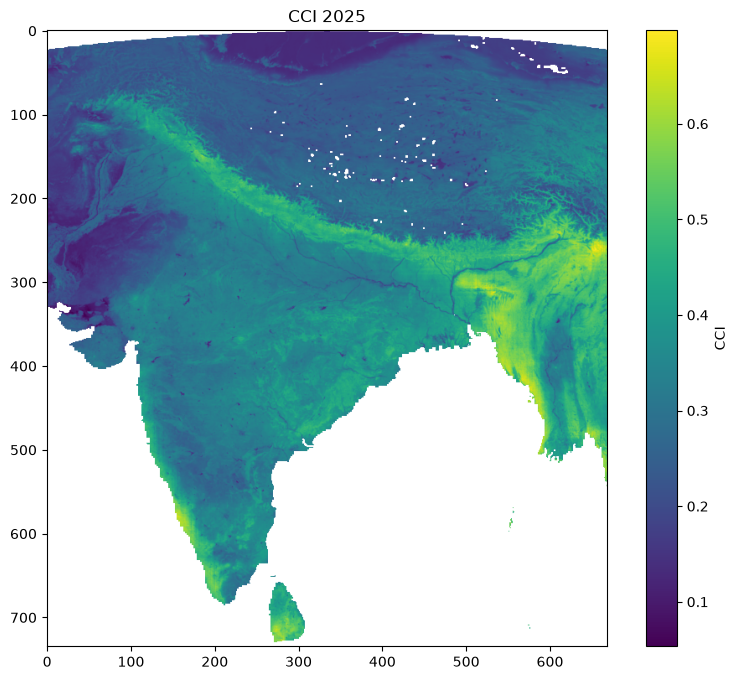

In [15]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open(r"E:\Major-project\Climate_Project\CCI_2025.tif") as src:
    cci_map = src.read(1)

plt.figure(figsize=(10,8))
plt.imshow(cci_map)
plt.colorbar(label="CCI")
plt.title("CCI 2025")
plt.show()

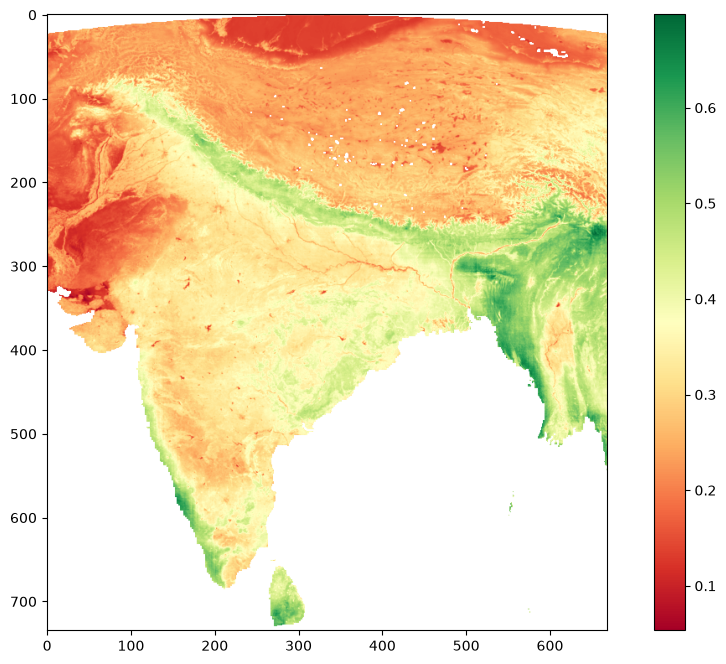

In [16]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open(r"E:\Major-project\Climate_Project\CCI_2025.tif") as src:
    cci = src.read(1)

plt.figure(figsize=(12,8))
plt.imshow(cci, cmap="RdYlGn")
plt.colorbar()
plt.show()

In [17]:
import json

future_data = future_df.to_dict(orient="records")

with open("predictions.json", "w") as f:
    json.dump(future_data, f, indent=4)

print("predictions.json created")

NameError: name 'future_df' is not defined

In [18]:
import pandas as pd

future_df = pd.DataFrame({
    "year":[2026,2027,2028,2029,2030,2031,2032],
    "ndvi":[0.354496,0.357254,0.360012,0.362771,0.365529,0.368287,0.371045],
    "rainfall":[968.606680,974.334274,980.061868,985.789462,991.517056,997.244650,1002.972244],
    "temperature":[14.076945,14.104690,14.132436,14.160181,14.187926,14.215672,14.243417],
    "cci":[0.731224,0.770184,0.809143,0.848103,0.887062,0.926022,0.964982]
})

future_df

,year,ndvi,rainfall,temperature,cci
0,2026,0.354496,968.606680,14.076945,0.731224
1,2027,0.357254,974.334274,14.104690,0.770184
2,2028,0.360012,980.061868,14.132436,0.809143
3,2029,0.362771,985.789462,14.160181,0.848103
4,2030,0.365529,991.517056,14.187926,0.887062
5,2031,0.368287,997.244650,14.215672,0.926022
6,2032,0.371045,1002.972244,14.243417,0.964982


In [19]:
import json

future_data = future_df.to_dict(orient="records")

with open("predictions.json", "w") as f:
    json.dump(future_data, f, indent=4)

print("predictions.json created")

predictions.json created


In [13]:
output_path = r"E:\Major-project\Climate_Project\CCI_2025.tif"

with rasterio.open(rainfall_path) as src:

    profile = src.profile

    profile.update(
        dtype=rasterio.float32,
        count=1
    )

    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(cci.astype(rasterio.float32), 1)

print("Saved:", output_path)

Saved: E:\Major-project\Climate_Project\CCI_2025.tif


In [14]:
import os

print(os.path.exists(r"E:\Major-project\Climate_Project\CCI_2025.tif"))

True


In [30]:
import numpy as np

print("Minimum:", np.nanmin(data))
print("Maximum:", np.nanmax(data))
print("Mean:", np.nanmean(data))

Minimum: -19.704861285865917
Maximum: 28.502353183672653
Mean: 14.162096931206214


In [1]:
import os

print(os.getcwd())

e:\Major-project\Climate-Impact-Assessment-main\Climate-Impact-Assessment-main\frontend


In [ ]:
import os

print(os.path.exists("future_predictions.json"))

True


In [31]:
import rasterio

path = r"E:\Major-project\Climate_Project\NDVI\India_NDVI_2015.tif"

with rasterio.open(path) as src:
    data = src.read(1)

print(data.shape)
print(data.dtype)

(14681, 13360)
float64
